In [7]:
import networkx as nx
import numpy as np
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def load_networkx(file):
    with open(file) as infile:
        network = json.load(infile)
    G = nx.readwrite.json_graph.cytoscape_graph(network)
    return G

In [8]:
def dens(G):
    posible_edges = 0.5 * G.number_of_nodes() * (G.number_of_nodes()-1)
    return G.size(weight='weight')/posible_edges

def dens_bip(Gij, nodes_i, weight=True):
    """
    Gij: bipartite network (only edges between i and j)
    nodes_i: nodes from group i
    """
    ni = len(nodes_i)
    nij = Gij.number_of_nodes()
    nj = nij - ni
    m = Gij.number_of_edges()
    if weight:
        return Gij.size(weight='weight') / float(ni * nj)
    else:
        return m / float(ni * nj)

In [5]:
G_biom = load_networkx('../results_mi/MOLECULAR_network_weighted_mi.json')
G_gene = load_networkx('../results_mi/GENETIC_network_weighted_mi.json')
G_mri = load_networkx('../results_mi/MRI_network_weighted_mi.json')
G_pet = load_networkx('../results_mi/PET_network_weighted_mi.json')
G_phen = load_networkx('../results_mi/PHENOTYPE_network_weighted_mi.json')
G_risk = load_networkx('../results_mi/RISKFACTORS_network_weighted_mi.json')
G_gene_biom = load_networkx('../results_mi/GENETIC_MOLECULAR_network_weighted_mi.json')
G_gene_biom.remove_edges_from(G_biom.edges())
G_gene_biom.remove_edges_from(G_gene.edges())
G_gene_pet = load_networkx('../results_mi/GENETIC_PET_network_weighted_mi.json')
G_gene_pet.remove_edges_from(G_pet.edges())
G_gene_pet.remove_edges_from(G_gene.edges())
G_gene_mri = load_networkx('../results_mi/GENETIC_MRI_network_weighted_mi.json')
G_gene_mri.remove_edges_from(G_mri.edges())
G_gene_mri.remove_edges_from(G_gene.edges())
G_gene_risk = load_networkx('../results_mi/GENETIC_RISKFACTORS_network_weighted_mi.json')
G_gene_risk.remove_edges_from(G_risk.edges())
G_gene_risk.remove_edges_from(G_gene.edges())
G_gene_phen = load_networkx('../results_mi/GENETIC_PHENOTYPE_network_weighted_mi.json')
G_gene_phen.remove_edges_from(G_phen.edges())
G_gene_phen.remove_edges_from(G_gene.edges())
G_biom_pet = load_networkx('../results_mi/MOLECULAR_PET_network_weighted_mi.json')
G_biom_pet.remove_edges_from(G_biom.edges())
G_biom_pet.remove_edges_from(G_pet.edges())
G_biom_mri = load_networkx('../results_mi/MOLECULAR_MRI_network_weighted_mi.json')
G_biom_mri.remove_edges_from(G_biom.edges())
G_biom_mri.remove_edges_from(G_mri.edges())
G_biom_risk = load_networkx('../results_mi/MOLECULAR_RISKFACTORS_network_weighted_mi.json')
G_biom_risk.remove_edges_from(G_biom.edges())
G_biom_risk.remove_edges_from(G_risk.edges())
G_biom_phen = load_networkx('../results_mi/MOLECULAR_PHENOTYPE_network_weighted_mi.json')
G_biom_phen.remove_edges_from(G_biom.edges())
G_biom_phen.remove_edges_from(G_phen.edges())
G_pet_phen = load_networkx('../results_mi/PET_PHENOTYPE_network_weighted_mi.json')
G_pet_phen.remove_edges_from(G_phen.edges())
G_pet_phen.remove_edges_from(G_pet.edges())
G_mri_pet = load_networkx('../results_mi/PET_MRI_network_weighted_mi.json')
G_mri_pet.remove_edges_from(G_mri.edges())
G_mri_pet.remove_edges_from(G_pet.edges())
G_mri_phen = load_networkx('../results_mi/MRI_PHENOTYPE_network_weighted_mi.json')
G_mri_phen.remove_edges_from(G_mri.edges())
G_mri_phen.remove_edges_from(G_phen.edges())
G_risk_mri = load_networkx('../results_mi/MRI_RISKFACTORS_network_weighted_mi.json')
G_risk_mri.remove_edges_from(G_mri.edges())
G_risk_mri.remove_edges_from(G_risk.edges())
G_risk_pet = load_networkx('../results_mi/PET_RISKFACTORS_network_weighted_mi.json')
G_risk_pet.remove_edges_from(G_risk.edges())
G_risk_pet.remove_edges_from(G_pet.edges())
G_risk_phen = load_networkx('../results_mi/RISKFACTORS_PHENOTYPE_network_weighted_mi.json')
G_risk_phen.remove_edges_from(G_risk.edges())
G_risk_phen.remove_edges_from(G_phen.edges())

In [9]:
a_density = np.array([[dens(G_gene)/dens(G_gene), dens_bip(G_gene_biom, G_gene.nodes())/np.sqrt(dens(G_gene)*dens(G_biom)), dens_bip(G_gene_pet, G_gene.nodes())/np.sqrt(dens(G_gene)*dens(G_pet)), dens_bip(G_gene_mri, G_gene.nodes())/np.sqrt(dens(G_gene)*dens(G_mri)), dens_bip(G_gene_phen, G_gene.nodes())/np.sqrt(dens(G_gene)*dens(G_phen)), dens_bip(G_gene_risk, G_gene.nodes())/np.sqrt(dens(G_gene)*dens(G_risk))],
[dens_bip(G_gene_biom, G_gene.nodes())/np.sqrt(dens(G_gene)*dens(G_biom)), dens(G_biom)/dens(G_biom), dens_bip(G_biom_pet, G_biom.nodes())/np.sqrt(dens(G_biom)*dens(G_pet)), dens_bip(G_biom_mri, G_biom.nodes())/np.sqrt(dens(G_biom)*dens(G_mri)), dens_bip(G_biom_phen, G_biom.nodes())/np.sqrt(dens(G_biom)*dens(G_phen)), dens_bip(G_biom_risk, G_biom.nodes())/np.sqrt(dens(G_biom)*dens(G_risk))],
[dens_bip(G_gene_pet, G_pet.nodes())/np.sqrt(dens(G_gene)*dens(G_pet)), dens_bip(G_biom_pet, G_pet.nodes())/np.sqrt(dens(G_biom)*dens(G_pet)), dens(G_pet)/dens(G_pet), dens_bip(G_mri_pet, G_pet.nodes())/np.sqrt(dens(G_pet)*dens(G_mri)), dens_bip(G_pet_phen, G_pet.nodes())/np.sqrt(dens(G_pet)*dens(G_phen)), dens_bip(G_risk_pet, G_pet.nodes())/np.sqrt(dens(G_pet)*dens(G_risk))],
[dens_bip(G_gene_mri, G_mri.nodes())/np.sqrt(dens(G_gene)*dens(G_mri)), dens_bip(G_biom_mri, G_mri.nodes())/np.sqrt(dens(G_biom)*dens(G_mri)), dens_bip(G_mri_pet, G_mri.nodes())/np.sqrt(dens(G_pet)*dens(G_mri)), dens(G_mri)/dens(G_mri), dens_bip(G_mri_phen, G_mri.nodes())/np.sqrt(dens(G_mri)*dens(G_phen)), dens_bip(G_risk_mri, G_mri.nodes())/np.sqrt(dens(G_mri)*dens(G_risk))],
[dens_bip(G_gene_phen, G_phen.nodes())/np.sqrt(dens(G_gene)*dens(G_phen)), dens_bip(G_biom_phen, G_phen.nodes())/np.sqrt(dens(G_biom)*dens(G_phen)), dens_bip(G_pet_phen, G_phen.nodes())/np.sqrt(dens(G_pet)*dens(G_phen)), dens_bip(G_mri_phen, G_phen.nodes())/np.sqrt(dens(G_mri)*dens(G_phen)), dens(G_phen)/dens(G_phen), dens_bip(G_risk_phen, G_phen.nodes())/np.sqrt(dens(G_phen)*dens(G_risk))],
[dens_bip(G_gene_risk, G_risk.nodes())/np.sqrt(dens(G_gene)*dens(G_risk)), dens_bip(G_biom_risk, G_risk.nodes())/np.sqrt(dens(G_biom)*dens(G_risk)), dens_bip(G_risk_pet, G_risk.nodes())/np.sqrt(dens(G_pet)*dens(G_risk)), dens_bip(G_risk_mri, G_risk.nodes())/np.sqrt(dens(G_mri)*dens(G_risk)), dens_bip(G_risk_phen, G_risk.nodes())/np.sqrt(dens(G_phen)*dens(G_risk)), dens(G_risk)/dens(G_risk)]])


df = pd.DataFrame(a_density, columns=['Genetic', 'Molecular', 'PET', 'MRI', 'Phenotype', 'Risk Factors'],
index=['Genetic', 'Molecular', 'PET', 'MRI', 'Phenotype', 'Risk Factors'])
df.round(3)

,Genetic,Molecular,PET,MRI,Phenotype,Risk Factors
Genetic,1.000,0.608,0.294,0.335,0.670,0.128
Molecular,0.608,1.000,0.485,0.341,0.578,0.208
PET,0.294,0.485,1.000,0.555,0.956,0.247
MRI,0.335,0.341,0.555,1.000,0.825,0.243
Phenotype,0.670,0.578,0.956,0.825,1.000,0.258
Risk Factors,0.128,0.208,0.247,0.243,0.258,1.000


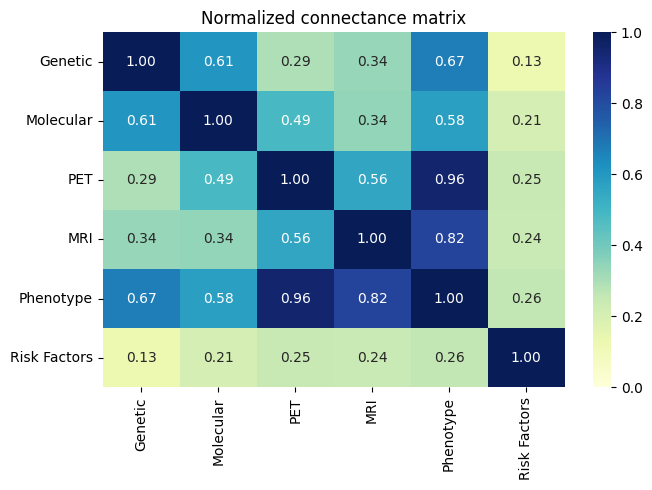

In [10]:
plt.figure(figsize=(7,5))
sns.heatmap(df, cmap="YlGnBu", annot=True, vmin=0, vmax=1, fmt='.2f')
plt.title('Normalized connectance matrix')
plt.tight_layout()
# plt.savefig('hm_m_pesos_norm.png', dpi=600)
plt.show()

In [11]:
a_density = np.array([[dens(G_gene), dens_bip(G_gene_biom, G_gene.nodes()), dens_bip(G_gene_pet, G_gene.nodes()), dens_bip(G_gene_mri, G_gene.nodes()), dens_bip(G_gene_phen, G_gene.nodes()), dens_bip(G_gene_risk, G_gene.nodes())],
[dens_bip(G_gene_biom, G_gene.nodes()), dens(G_biom), dens_bip(G_biom_pet, G_biom.nodes()), dens_bip(G_biom_mri, G_biom.nodes()), dens_bip(G_biom_phen, G_biom.nodes()), dens_bip(G_biom_risk, G_biom.nodes())],
[dens_bip(G_gene_pet, G_pet.nodes()), dens_bip(G_biom_pet, G_pet.nodes()), dens(G_pet), dens_bip(G_mri_pet, G_pet.nodes()), dens_bip(G_pet_phen, G_pet.nodes()), dens_bip(G_risk_pet, G_pet.nodes())],
[dens_bip(G_gene_mri, G_mri.nodes()), dens_bip(G_biom_mri, G_mri.nodes()), dens_bip(G_mri_pet, G_mri.nodes()), dens(G_mri), dens_bip(G_mri_phen, G_mri.nodes()), dens_bip(G_risk_mri, G_mri.nodes())],
[dens_bip(G_gene_phen, G_phen.nodes()), dens_bip(G_biom_phen, G_phen.nodes()), dens_bip(G_pet_phen, G_phen.nodes()), dens_bip(G_mri_phen, G_phen.nodes()), dens(G_phen), dens_bip(G_risk_phen, G_phen.nodes())],
[dens_bip(G_gene_risk, G_risk.nodes()), dens_bip(G_biom_risk, G_risk.nodes()), dens_bip(G_risk_pet, G_risk.nodes()), dens_bip(G_risk_mri, G_risk.nodes()), dens_bip(G_risk_phen, G_risk.nodes()), dens(G_risk)]])


df = pd.DataFrame(a_density, columns=['Genetic', 'Molecular', 'PET', 'MRI', 'Phenotype', 'Risk Factors'],
index=['Genetic', 'Molecular', 'PET', 'MRI', 'Phenotype', 'Risk Factors'])
df.round(3)

,Genetic,Molecular,PET,MRI,Phenotype,Risk Factors
Genetic,0.323,0.208,0.097,0.152,0.257,0.008
Molecular,0.208,0.363,0.170,0.164,0.235,0.014
PET,0.097,0.170,0.339,0.259,0.377,0.017
MRI,0.152,0.164,0.259,0.640,0.446,0.022
Phenotype,0.257,0.235,0.377,0.446,0.457,0.020
Risk Factors,0.008,0.014,0.017,0.022,0.020,0.013


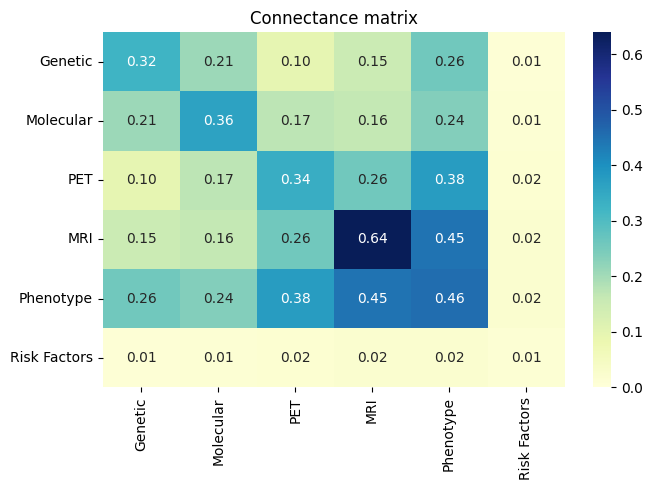

In [12]:
plt.figure(figsize=(7,5))
sns.heatmap(df, cmap="YlGnBu", annot=True, vmin=0, fmt='.2f')
plt.title('Connectance matrix')
plt.tight_layout()
plt.savefig('../imagenes/matrix_pesos.png', dpi=600)
plt.show()

In [16]:
def dens(G):
    return nx.density(G)
def dens_bip(G, nodes):
    return nx.bipartite.density(G, nodes)

G_biom = load_networkx('../results_mi/MOLECULAR_network_unweighted_mi.json')
G_gene = load_networkx('../results_mi/GENETIC_network_unweighted_mi.json')
G_mri = load_networkx('../results_mi/MRI_network_unweighted_mi.json')
G_pet = load_networkx('../results_mi/PET_network_unweighted_mi.json')
G_phen = load_networkx('../results_mi/PHENOTYPE_network_unweighted_mi.json')
G_risk = load_networkx('../results_mi/RISKFACTORS_network_unweighted_mi.json')
G_gene_biom = load_networkx('../results_mi/GENETIC_MOLECULAR_network_unweighted_mi.json')
G_gene_biom.remove_edges_from(G_biom.edges())
G_gene_biom.remove_edges_from(G_gene.edges())
G_gene_pet = load_networkx('../results_mi/GENETIC_PET_network_unweighted_mi.json')
G_gene_pet.remove_edges_from(G_pet.edges())
G_gene_pet.remove_edges_from(G_gene.edges())
G_gene_mri = load_networkx('../results_mi/GENETIC_MRI_network_unweighted_mi.json')
G_gene_mri.remove_edges_from(G_mri.edges())
G_gene_mri.remove_edges_from(G_gene.edges())
G_gene_risk = load_networkx('../results_mi/GENETIC_RISKFACTORS_network_unweighted_mi.json')
G_gene_risk.remove_edges_from(G_risk.edges())
G_gene_risk.remove_edges_from(G_gene.edges())
G_gene_phen = load_networkx('../results_mi/GENETIC_PHENOTYPE_network_unweighted_mi.json')
G_gene_phen.remove_edges_from(G_phen.edges())
G_gene_phen.remove_edges_from(G_gene.edges())
G_biom_pet = load_networkx('../results_mi/MOLECULAR_PET_network_unweighted_mi.json')
G_biom_pet.remove_edges_from(G_biom.edges())
G_biom_pet.remove_edges_from(G_pet.edges())
G_biom_mri = load_networkx('../results_mi/MOLECULAR_MRI_network_unweighted_mi.json')
G_biom_mri.remove_edges_from(G_biom.edges())
G_biom_mri.remove_edges_from(G_mri.edges())
G_biom_risk = load_networkx('../results_mi/MOLECULAR_RISKFACTORS_network_unweighted_mi.json')
G_biom_risk.remove_edges_from(G_biom.edges())
G_biom_risk.remove_edges_from(G_risk.edges())
G_biom_phen = load_networkx('../results_mi/MOLECULAR_PHENOTYPE_network_unweighted_mi.json')
G_biom_phen.remove_edges_from(G_biom.edges())
G_biom_phen.remove_edges_from(G_phen.edges())
G_pet_phen = load_networkx('../results_mi/PET_PHENOTYPE_network_unweighted_mi.json')
G_pet_phen.remove_edges_from(G_phen.edges())
G_pet_phen.remove_edges_from(G_pet.edges())
G_mri_pet = load_networkx('../results_mi/PET_MRI_network_unweighted_mi.json')
G_mri_pet.remove_edges_from(G_mri.edges())
G_mri_pet.remove_edges_from(G_pet.edges())
G_mri_phen = load_networkx('../results_mi/MRI_PHENOTYPE_network_unweighted_mi.json')
G_mri_phen.remove_edges_from(G_mri.edges())
G_mri_phen.remove_edges_from(G_phen.edges())
G_risk_mri = load_networkx('../results_mi/MRI_RISKFACTORS_network_unweighted_mi.json')
G_risk_mri.remove_edges_from(G_mri.edges())
G_risk_mri.remove_edges_from(G_risk.edges())
G_risk_pet = load_networkx('../results_mi/PET_RISKFACTORS_network_unweighted_mi.json')
G_risk_pet.remove_edges_from(G_risk.edges())
G_risk_pet.remove_edges_from(G_pet.edges())
G_risk_phen = load_networkx('../results_mi/RISKFACTORS_PHENOTYPE_network_unweighted_mi.json')
G_risk_phen.remove_edges_from(G_risk.edges())
G_risk_phen.remove_edges_from(G_phen.edges())

a_density = np.array([[dens(G_gene)/dens(G_gene), dens_bip(G_gene_biom, G_gene.nodes())/np.sqrt(dens(G_gene)*dens(G_biom)), dens_bip(G_gene_pet, G_gene.nodes())/np.sqrt(dens(G_gene)*dens(G_pet)), dens_bip(G_gene_mri, G_gene.nodes())/np.sqrt(dens(G_gene)*dens(G_mri)), dens_bip(G_gene_phen, G_gene.nodes())/np.sqrt(dens(G_gene)*dens(G_phen)), dens_bip(G_gene_risk, G_gene.nodes())/np.sqrt(dens(G_gene)*dens(G_risk))],
[dens_bip(G_gene_biom, G_gene.nodes())/np.sqrt(dens(G_gene)*dens(G_biom)), dens(G_biom)/dens(G_biom), dens_bip(G_biom_pet, G_biom.nodes())/np.sqrt(dens(G_biom)*dens(G_pet)), dens_bip(G_biom_mri, G_biom.nodes())/np.sqrt(dens(G_biom)*dens(G_mri)), dens_bip(G_biom_phen, G_biom.nodes())/np.sqrt(dens(G_biom)*dens(G_phen)), dens_bip(G_biom_risk, G_biom.nodes())/np.sqrt(dens(G_biom)*dens(G_risk))],
[dens_bip(G_gene_pet, G_pet.nodes())/np.sqrt(dens(G_gene)*dens(G_pet)), dens_bip(G_biom_pet, G_pet.nodes())/np.sqrt(dens(G_biom)*dens(G_pet)), dens(G_pet)/dens(G_pet), dens_bip(G_mri_pet, G_pet.nodes())/np.sqrt(dens(G_pet)*dens(G_mri)), dens_bip(G_pet_phen, G_pet.nodes())/np.sqrt(dens(G_pet)*dens(G_phen)), dens_bip(G_risk_pet, G_pet.nodes())/np.sqrt(dens(G_pet)*dens(G_risk))],
[dens_bip(G_gene_mri, G_mri.nodes())/np.sqrt(dens(G_gene)*dens(G_mri)), dens_bip(G_biom_mri, G_mri.nodes())/np.sqrt(dens(G_biom)*dens(G_mri)), dens_bip(G_mri_pet, G_mri.nodes())/np.sqrt(dens(G_pet)*dens(G_mri)), dens(G_mri)/dens(G_mri), dens_bip(G_mri_phen, G_mri.nodes())/np.sqrt(dens(G_mri)*dens(G_phen)), dens_bip(G_risk_mri, G_mri.nodes())/np.sqrt(dens(G_mri)*dens(G_risk))],
[dens_bip(G_gene_phen, G_phen.nodes())/np.sqrt(dens(G_gene)*dens(G_phen)), dens_bip(G_biom_phen, G_phen.nodes())/np.sqrt(dens(G_biom)*dens(G_phen)), dens_bip(G_pet_phen, G_phen.nodes())/np.sqrt(dens(G_pet)*dens(G_phen)), dens_bip(G_mri_phen, G_phen.nodes())/np.sqrt(dens(G_mri)*dens(G_phen)), dens(G_phen)/dens(G_phen), dens_bip(G_risk_phen, G_phen.nodes())/np.sqrt(dens(G_phen)*dens(G_risk))],
[dens_bip(G_gene_risk, G_risk.nodes())/np.sqrt(dens(G_gene)*dens(G_risk)), dens_bip(G_biom_risk, G_risk.nodes())/np.sqrt(dens(G_biom)*dens(G_risk)), dens_bip(G_risk_pet, G_risk.nodes())/np.sqrt(dens(G_pet)*dens(G_risk)), dens_bip(G_risk_mri, G_risk.nodes())/np.sqrt(dens(G_mri)*dens(G_risk)), dens_bip(G_risk_phen, G_risk.nodes())/np.sqrt(dens(G_phen)*dens(G_risk)), dens(G_risk)/dens(G_risk)]])


df = pd.DataFrame(a_density, columns=['Genetic', 'Molecular', 'PET', 'MRI', 'Phenotype', 'Risk Factors'],
index=['Genetic', 'Molecular', 'PET', 'MRI', 'Phenotype', 'Risk Factors'])
df.round(3)

,Genetic,Molecular,PET,MRI,Phenotype,Risk Factors
Genetic,1.000,0.720,0.391,0.369,0.821,0.279
Molecular,0.720,1.000,0.480,0.347,0.576,0.230
PET,0.391,0.480,1.000,0.532,0.908,0.277
MRI,0.369,0.347,0.532,1.000,0.830,0.295
Phenotype,0.821,0.576,0.908,0.830,1.000,0.366
Risk Factors,0.279,0.230,0.277,0.295,0.366,1.000


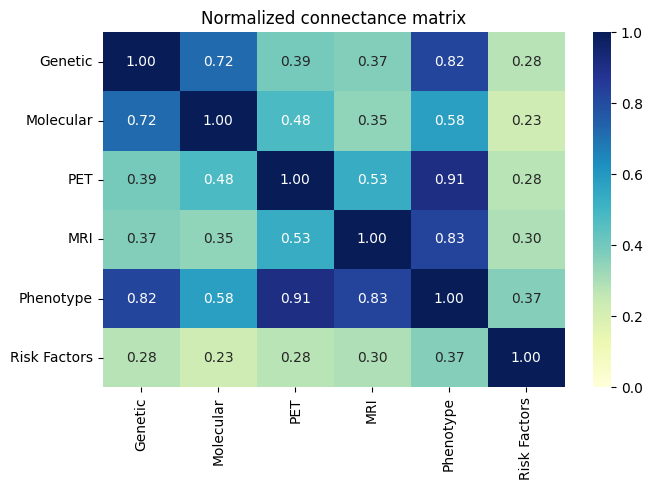

In [17]:
plt.figure(figsize=(7,5))
sns.heatmap(df, cmap="YlGnBu", annot=True, vmin=0, vmax=1, fmt='.2f')
plt.title('Normalized connectance matrix')
plt.tight_layout()
# plt.savefig('hm_m_edges_norm.png', dpi=600)
plt.show()

In [18]:
a_density = np.array([[dens(G_gene), dens_bip(G_gene_biom, G_gene.nodes()), dens_bip(G_gene_pet, G_gene.nodes()), dens_bip(G_gene_mri, G_gene.nodes()), dens_bip(G_gene_phen, G_gene.nodes()), dens_bip(G_gene_risk, G_gene.nodes())],
[dens_bip(G_gene_biom, G_gene.nodes()), dens(G_biom), dens_bip(G_biom_pet, G_biom.nodes()), dens_bip(G_biom_mri, G_biom.nodes()), dens_bip(G_biom_phen, G_biom.nodes()), dens_bip(G_biom_risk, G_biom.nodes())],
[dens_bip(G_gene_pet, G_pet.nodes()), dens_bip(G_biom_pet, G_pet.nodes()), dens(G_pet), dens_bip(G_mri_pet, G_pet.nodes()), dens_bip(G_pet_phen, G_pet.nodes()), dens_bip(G_risk_pet, G_pet.nodes())],
[dens_bip(G_gene_mri, G_mri.nodes()), dens_bip(G_biom_mri, G_mri.nodes()), dens_bip(G_mri_pet, G_mri.nodes()), dens(G_mri), dens_bip(G_mri_phen, G_mri.nodes()), dens_bip(G_risk_mri, G_mri.nodes())],
[dens_bip(G_gene_phen, G_phen.nodes()), dens_bip(G_biom_phen, G_phen.nodes()), dens_bip(G_pet_phen, G_phen.nodes()), dens_bip(G_mri_phen, G_phen.nodes()), dens(G_phen), dens_bip(G_risk_phen, G_phen.nodes())],
[dens_bip(G_gene_risk, G_risk.nodes()), dens_bip(G_biom_risk, G_risk.nodes()), dens_bip(G_risk_pet, G_risk.nodes()), dens_bip(G_risk_mri, G_risk.nodes()), dens_bip(G_risk_phen, G_risk.nodes()), dens(G_risk)]])


df = pd.DataFrame(a_density, columns=['Genetic', 'Molecular', 'PET', 'MRI', 'Phenotype', 'Risk Factors'],
index=['Genetic', 'Molecular', 'PET', 'MRI', 'Phenotype', 'Risk Factors'])
df.round(3)

,Genetic,Molecular,PET,MRI,Phenotype,Risk Factors
Genetic,1.000,0.454,0.228,0.316,0.821,0.171
Molecular,0.454,0.397,0.176,0.187,0.363,0.089
PET,0.228,0.176,0.340,0.266,0.530,0.099
MRI,0.316,0.187,0.266,0.732,0.710,0.155
Phenotype,0.821,0.363,0.530,0.710,1.000,0.225
Risk Factors,0.171,0.089,0.099,0.155,0.225,0.378


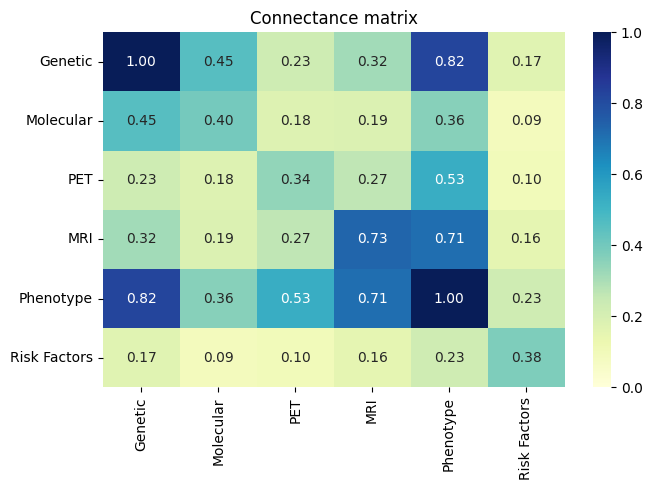

In [19]:
plt.figure(figsize=(7,5))
sns.heatmap(df, cmap="YlGnBu", annot=True, vmin=0, fmt='.2f')
plt.title('Connectance matrix')
plt.tight_layout()
# plt.savefig('hm_m_edges.png', dpi=600)
plt.show()